# **Homework4: Feature representation for Graphs**

 - Answer the questions marked with **Questions # )** . Just answer the parts where it says: **" write your answer here. "**
 > **You should write the codes here in this notebook and write a report for explanations in a separate pdf file.**

 * Total score: 100 score and 100 bonus additive points
 * Bonus questions are optional and their score is additive only for this homework. For this notebook answering just the bonus question is enough and will cover all the main score.
 *  **Do not** alter the pre-written code. You can add arguments to the functions but **do not** remove any input arguments.
 *  You can use both pyg and network_x version of the dataset but remember that the pyg data has twice edges (format of undirected graphs in pyg) and should be converted.
 *  You can also use whatever package you want for the feature calculation






## **Load your dataset from pyg library**

To start, we will load a classic graph in network science. We will explore multiple graph statistics for that graph.

### **Cora dataset**

Dataset description: The Cora dataset consists of scientific publications classified into one of seven classes. Each publication in the dataset is described by a 0/1-valued word vector indicating the absence/presence of the corresponding word from the dictionary.

[More Information of the dataset](https://paperswithcode.com/dataset/cora#:~:text=The%20Cora%20dataset%20consists%20of,corresponding%20word%20from%20the%20dictionary.)

*   Nodes : Publications (Papers, Books …)
*   Edges : Citations
*   Node Features : word vectors
*   7 Labels : Publication type e.g. Neural_Networks, Rule_Learning, Reinforcement_Learning, Probabilistic_Methods

In [1]:
#!pip install torch_geometric

import os
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import torch
from torch import Tensor
import torch_geometric
from torch_geometric.utils import to_networkx
from torch_geometric.datasets import Planetoid
import networkx as nx
from networkx.algorithms import community

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

In [2]:
dataset = Planetoid(root=data_dir, name='Cora')
pyg_data = dataset[0]
networkx_data = to_networkx(pyg_data, to_undirected=True)

## **EDA**

**Questions 1 ) (10 points)** Write a function that gets the graph as input and prints:

*   Number of nodes
*   Number of edges
*   If graph has node features / dimnesion of node features
*   If graph has edge features / dimnesion of edge features
*   If graph has isolated nodes / number of isolated nodes
*   If graph has self-loops / number of self-loops
*   If graph is undirected



In [3]:
def print_graph_stat(graph):
    # Number of nodes
    print(f'Number of nodes: {graph.number_of_nodes()}')
    
    # Number of edges
    print(f'Number of edges: {graph.number_of_edges()}')
    
    # Node features (assuming node features are stored as attributes in each node)
    node_features = list(graph.nodes(data=True))
    if node_features and any('features' in data for _, data in node_features):
        feature_dims = set(len(data['features']) for _, data in node_features if 'features' in data)
        print(f"Graph has node features with dimensions: {feature_dims}")
    else:
        print("Graph has no node features")

    # Edge features (assuming edge features are stored as attributes in each edge)
    edge_features = list(graph.edges(data=True))
    if edge_features and any('features' in data for _, _, data in edge_features):
        edge_feature_dims = set(len(data['features']) for _, _, data in edge_features if 'features' in data)
        print(f"Graph has edge features with dimensions: {edge_feature_dims}")
    else:
        print("Graph has no edge features")

    # Isolated nodes
    print(f'Number of isolated nodes: {nx.number_of_isolates(graph)}')

    # Self-loops
    print(f'Number of self-loops: {nx.number_of_selfloops(graph)}')
    
    print(f'Graph is {"directed" if graph.is_directed() else "not directed"}')

print_graph_stat(networkx_data)
# or print_graph_stat(pyg_data)

Number of nodes: 2708
Number of edges: 5278
Graph has no node features
Graph has no edge features
Number of isolated nodes: 0
Number of self-loops: 0
Graph is not directed


**Questions 2 ) (10 points)** Write a function that gets the graph and visualizes it with spring_layout (networkx).

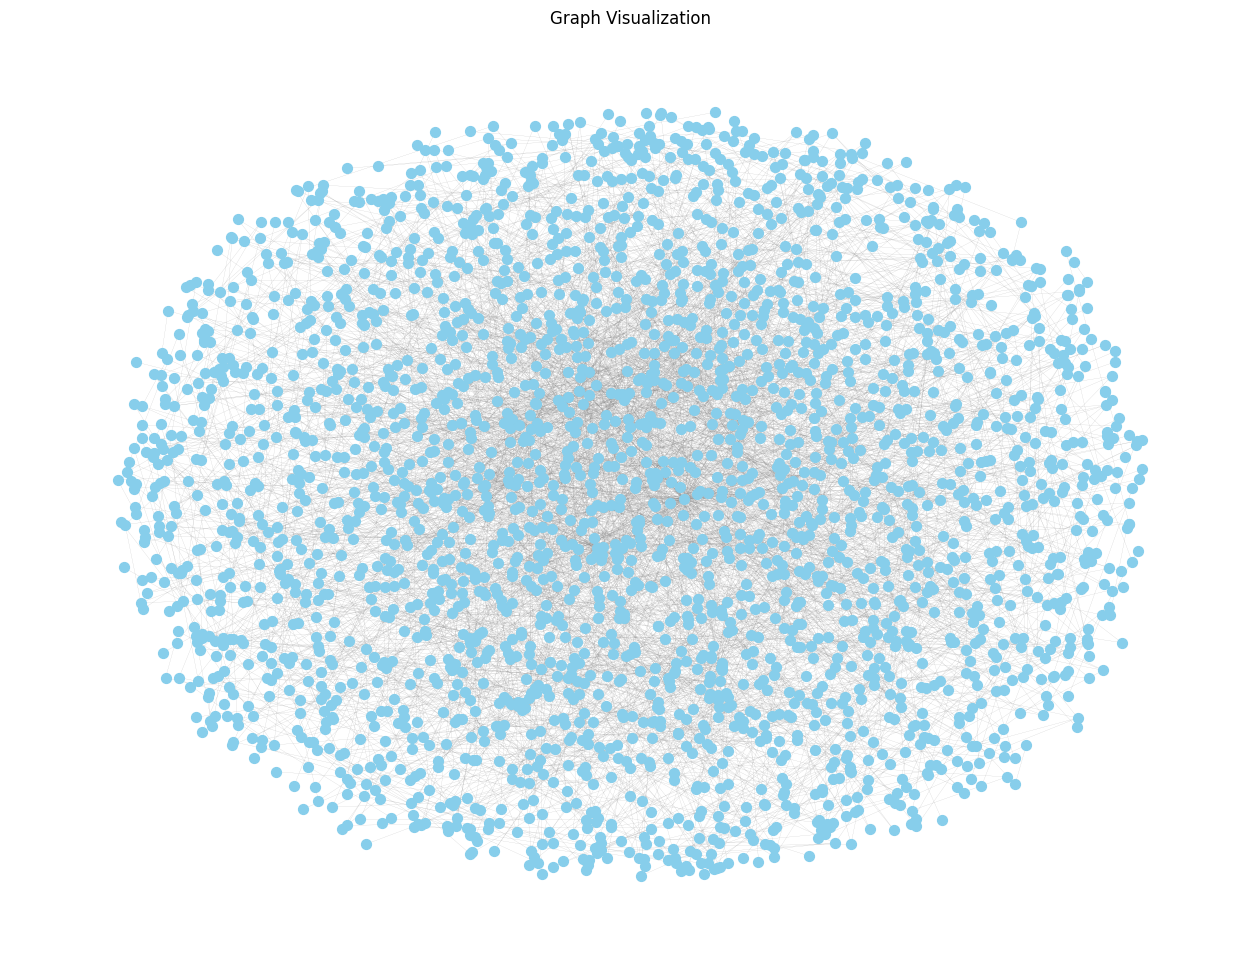

In [4]:
def visualize_graph(graph):
    # Generate positions for all nodes using the spring layout
    pos = nx.spring_layout(graph, k=0.2)

    # Create a figure
    plt.figure(figsize=(16, 12))

    nx.draw_networkx_nodes(graph, pos, node_size=50, node_color='skyblue')
    nx.draw_networkx_edges(graph, pos, width=0.1, edge_color='gray', alpha=0.7)

    # Set title and remove axes
    plt.title('Graph Visualization')
    plt.axis('off')

    # Show the plot
    plt.show()

visualize_graph(networkx_data)

## **Node-Level feature**

**Questions 3 ) (10 points)** Write a function that gets the Cora network graph and prints:

*   the list of degrees and its average
*   the list of clustering coefficients and its average
*   the list of closeness centralities and its average
*   the list of eigenvector centralities and its average
*   the list of betweenness centralities and its average

Explain how each information may come in handy for this dataset. Are they even informative enough in this dataset to be used for classification? show this by taking a node for example and print its feature.

In [5]:
def node_level_feature_graph(graph):
    nodes_features = {node: {} for node in list(graph.nodes)}
    # List of degrees and its average
    graph_degree = graph.degree()
    avg_degree = np.mean([d for _,d in graph_degree])
    for node, degree in graph_degree:
        nodes_features[node]['degree'] = degree
    
    # List of clustering coefficients and its average
    graph_clustering_coeffs = nx.clustering(graph)
    avg_clustering_coeffs = np.mean(list(graph_clustering_coeffs.values()))
    for node, value in graph_clustering_coeffs.items():
        nodes_features[node]['clustering_coeffs'] = round(value, 3)
    
    # List of closeness centralities and its average
    graph_closeness_centrality = nx.closeness_centrality(graph)
    avg_closeness_centrality = np.mean(list(graph_closeness_centrality.values()))
    for node, value in graph_closeness_centrality.items():
        nodes_features[node]['closeness_centrality'] = round(value, 3)
    
    # List of eigenvector centralities and its average
    graph_eigenvector_centrality = nx.eigenvector_centrality(graph)
    avg_eigenvector_centrality = np.mean(list(graph_eigenvector_centrality.values()))
    for node, value in graph_eigenvector_centrality.items():
        nodes_features[node]['eigenvector_centrality'] = round(value, 3)
    
    # List of betweenness centralities and its average
    graph_betweenness_centrality = nx.betweenness_centrality(graph)
    avg_betweenness_centrality = np.mean(list(graph_betweenness_centrality.values()))
    for node, value in graph_betweenness_centrality.items():
        nodes_features[node]['betweenness_centrality'] = round(value, 3)
    
    print(f"""
    Average degree: {avg_degree:.4f}
    Average clustering coefficient: {avg_clustering_coeffs:.4f}
    Average closeness centrality: {avg_closeness_centrality:.4f}
    Average eigenvector centrality: {avg_eigenvector_centrality:.4f}
    Average betweenness centrality: {avg_betweenness_centrality:.4f}
    """)
    
    print("{:<10} {:<10} {:<15} {:<15} {:<15} {:<15}".format('Node','Degree','Clustering','Closeness','Eigenvector','Betweenness'))
    for node, features in nodes_features.items():
        print("{:<10} {:<10} {:<15} {:<15} {:<15} {:<15}".format(node, features['degree'], features['clustering_coeffs'], features['closeness_centrality'], features['eigenvector_centrality'],features['betweenness_centrality']))
    
node_level_feature_graph(networkx_data)


    Average degree: 3.8981
    Average clustering coefficient: 0.2407
    Average closeness centrality: 0.1375
    Average eigenvector centrality: 0.0048
    Average betweenness centrality: 0.0017
    
Node       Degree     Clustering      Closeness       Eigenvector     Betweenness    
0          3          0.333           0.144           0.0             0.0            
1          3          0               0.151           0.0             0.001          
2          5          0               0.179           0.001           0.004          
3          1          0               0.0             0.0             0.0            
4          5          0.7             0.153           0.005           0.001          
5          3          0.333           0.13            0.001           0.0            
6          4          0.333           0.155           0.0             0.001          
7          1          0               0.0             0.0             0.0            
8          3          0

## **Edge-Level feature**

**Questions 4 ) (20 points)** Write a function that gets the Cora network graph and prints:

*   the list of shortest-path distance between two nodes
*   the list of common neighbors
*   the list of jaccard's coefficient
*   the list of adamic-Adar index

Explain how each information may come in handy for this dataset. Are they even informative enough in this dataset to be used for classification? show this by taking an edge for example and print its feature.

In [6]:
def edge_level_feature_graph(graph):
    nodes = list(graph.nodes())

    print("{:<10} {:<10} {:<15} {:<20} {:<25} {:<20}".format('Node1', 'Node2', 'Shortest path', 'Common neighbors', "Jaccard's coefficient", 'adamic-Adar index'))
    for node1 in nodes[:10]:
        for node2 in nodes[:10]:
            if node1 != node2:
                # Shortest path distance
                try:
                    shortest_path = nx.shortest_path_length(graph, source=node1, target=node2)
                except(nx.NetworkXNoPath):
                    shortest_path = "No path"

                # Common neighbors
                common_neighbors = list(nx.common_neighbors(graph, node1, node2))
                
                # Jaccard's coefficient
                jaccard_coefficient = nx.jaccard_coefficient(graph, [(node1, node2)])
                jaccard_coefficient_value = next(jaccard_coefficient)[2]

                # Adamic-Adar index
                adamic_adar_index = nx.adamic_adar_index(graph, [(node1, node2)])
                adamic_adar_index_value = next(adamic_adar_index)[2]

                # print(node1, node2, shortest_path, common_neighbors, jaccard_coefficient_value, adamic_adar_index_value)
                print("{:<10} {:<10} {:<15} {:<20} {:<25} {:<20}".format(node1, node2, shortest_path, str(common_neighbors), jaccard_coefficient_value, adamic_adar_index_value))

edge_level_feature_graph(networkx_data)

Node1      Node2      Shortest path   Common neighbors     Jaccard's coefficient     adamic-Adar index   
0          1          5               []                   0.0                       0                   
0          2          4               []                   0.0                       0                   
0          3          No path         []                   0.0                       0                   
0          4          7               []                   0.0                       0                   
0          5          8               []                   0.0                       0                   
0          6          8               []                   0.0                       0                   
0          7          No path         []                   0.0                       0                   
0          8          5               []                   0.0                       0                   
0          9          8               []      

## **Graph-Level feature**

**Questions 5 ) (50 points)** Write a function that calculates the graph feature using Weisfeiler-Lehman Kernel.

In [7]:
import hashlib
from collections import Counter

def wl_kernel_graph(graph):
    # Number of iterations for the WL label refinement
    steps = 3

    # Initialize node labels: all nodes start with the same label '1'
    node_labels = {node: '1' for node in graph.nodes}

    # Initialize the set of unique labels (colors)
    set_of_colors = set('1')

    # Perform WL label refinement
    for _ in range(steps):
        new_labels = {}
         # Iterate over each node in the graph
        for node in graph.nodes():
            # Get sorted labels of the node's neighbor
            neighbors = sorted([node_labels[neighbor] for neighbor in graph.neighbors(node)])
            # Create a new label by combining the node's current label with the sorted neighbor labels
            new_label = str(node_labels[node]) + ''.join(neighbors)
            # Hash the combined label to generate a new unique label
            new_label = hashlib.md5(new_label.encode('utf-8')).hexdigest()
            # Store the new label for the node
            new_labels[node] = new_label
            # Add the new label to the set of unique labels (colors)
            set_of_colors.add(new_label)

        # Update node labels for the next iteration
        node_labels = new_labels.copy()

    # Count the frequency of each label in the final iteration
    count_labels = Counter(node_labels.values())
    # Sort the set of unique labels (colors) to create a consistent order
    set_of_colors = sorted(list(set_of_colors))
    # Create the feature vector by counting occurrences of each label in the sorted set of colors
    feature_vactor = [count_labels.get(i, 0) for i in set_of_colors]

    return feature_vactor
        

wl_kernel_graph(networkx_data)

[1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 12,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 2,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 6,
 1,
 1,
 1,
 0,
 0,
 0,
 2,
 0,
 0,
 1,
 11,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 2,
 0,
 0,
 1,
 3,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 2,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 2,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 2,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1

# Bonus questions

**Question 1) (100 points)** Implement and calculate the graphlet feature vector for each node of this dataset. Answer should be complete and outputs a complete graphlet feature vector.

In [8]:
def graphlet(graph):

  " write your answer here. "

graphlet(networkx_data)